In [1]:
from proto import *
from engine import *

import pandas as pd
import numpy as np

In [2]:
disease_state_strat = Stratification("disease_state", ["S", "I", "R"])
humans = CompartmentMap.new(disease_state_strat)
humans.compartments

array([Compartment :[(Stratification: disease_state, 'S')],
       Compartment :[(Stratification: disease_state, 'I')],
       Compartment :[(Stratification: disease_state, 'R')]], dtype=object)

In [3]:
humans_aged, age_strat = humans.stratify(
    Stratification("age", ["child", "young_adult", "adult", "older"]), in_place=False
)

In [4]:
severity_strat = humans.stratify(
    Stratification("severity", ["mild", "severe"]), disease_state_strat["I"]
)

In [7]:
humans_aged.query([disease_state_strat["I"]])

CompartmentContainer view of 0x2055707253712:
array([Compartment :[(Stratification: disease_state, 'I'), (Stratification: age, 'child')],
       Compartment :[(Stratification: disease_state, 'I'), (Stratification: age, 'young_adult')],
       Compartment :[(Stratification: disease_state, 'I'), (Stratification: age, 'adult')],
       Compartment :[(Stratification: disease_state, 'I'), (Stratification: age, 'older')]],
      dtype=object)array([4, 5, 6, 7])

In [9]:
inf_age_cats = [
    [disease_state_strat["I"], age_strat[age_group]] for age_group in age_strat.strata
]

inf_age_cats

[[(Stratification: disease_state, ['I']), (Stratification: age, ['child'])],
 [(Stratification: disease_state, ['I']),
  (Stratification: age, ['young_adult'])],
 [(Stratification: disease_state, ['I']), (Stratification: age, ['adult'])],
 [(Stratification: disease_state, ['I']), (Stratification: age, ['older'])]]

In [8]:
age_comp_vals = jnp.linspace(1.0, 10.0, len(humans_aged.compartments))
acv_data = CompartmentDataContainer(
    humans_aged.compartments, humans_aged, age_comp_vals
)

In [9]:
query_cat_reduction(inf_age_cats, acv_data)

Array([4.2727275, 5.090909 , 5.909091 , 6.727273 ], dtype=float32)

In [10]:
def foi(cdatamap, params):
    ipop = cdatamap.query([disease_state_strat["I"]]).data.sum()
    total_pop = cdatamap.data.sum()
    return (ipop / total_pop) * params["contact_rate"]

In [11]:
mm = jnp.ones((len(h_age_strat.strata), len(h_age_strat.strata)))


def foi_mixing(cdatamap, params):
    ipops = query_cat_reduction(inf_age_cats, cdatamap)
    total_pop = cdatamap.data.sum()
    return mm @ ipops / total_pop * params["contact_rate"]

In [12]:
foi_mixing(acv_data, {"contact_rate": 1.0})

Array([0.33333334, 0.33333334, 0.33333334, 0.33333334], dtype=float32)

In [13]:
foi(acv_data, {"contact_rate": 1.0})

Array(0.33333334, dtype=float32)

In [14]:
inf_age_cats

[[(Stratification: disease_state, ['I']), (Stratification: age, ['child'])],
 [(Stratification: disease_state, ['I']),
  (Stratification: age, ['young_adult'])],
 [(Stratification: disease_state, ['I']), (Stratification: age, ['adult'])],
 [(Stratification: disease_state, ['I']), (Stratification: age, ['older'])]]

In [15]:
infection = TransitionFlow(disease_state_strat["S"], disease_state_strat["I"], "foi")

In [16]:
recovery = TransitionFlow(
    disease_state_strat["I"], disease_state_strat["R"], "recovery_rate"
)

In [19]:
flows = {"infection": infection, "recovery": recovery}

dyn_params = {"foi": foi}

model = NaiveModel(humans, flows, dyn_params)
run = model.get_runner()

Scatter
Gather


In [20]:
istate = jnp.array([100.0, 5.0, 0.0, 0.0])
params = {"contact_rate": 0.2, "recovery_rate": 0.01}
t = 200

comp_results = run(istate, params, t)

In [22]:
def compname(c: Compartment):
    return "_".join([stratum for (strat, stratum) in c.strata])

In [23]:
comp_labels = [compname(c) for c in model.cmap.compartments]

<Axes: >

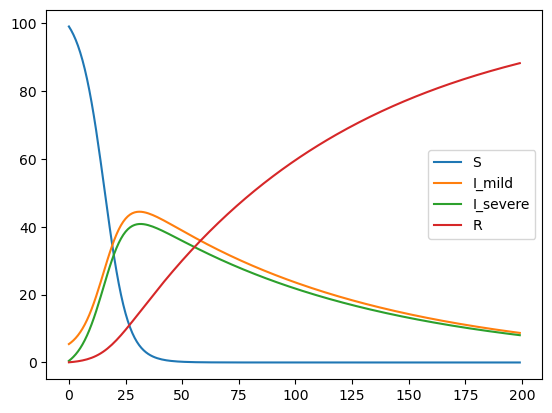

In [25]:
pd.DataFrame(comp_results, columns=comp_labels).plot()

In [ ]:
assert False

In [ ]:
def state_update(comp_vals, i):
    hdata = CompartmentDataContainer(humans.compartments, humans, comp_vals)
    for k, v in dyn_params.items():
        params[k] = v(hdata, params)

    comp_delta = jnp.zeros_like(comp_vals)
    for flow in flows:
        flow_vals = flow.get_flow_vals(hdata, params)
        comp_delta = comp_delta.at[flow.src_cmap.indices].subtract(flow_vals)
        comp_delta = comp_delta.at[flow.dest_cmap.indices].add(flow_vals)
    tstep_data = jnp.clip(hdata.data + comp_delta, 0.0)

    return tstep_data, tstep_data


def run_model(init_state, params, timesteps):
    final, gathered = lax.scan(state_update, init_state, length=timesteps)
    return gathered

In [ ]:
def thing(n):
    return jnp.ones(n)

In [ ]:
jit(thing, static_argnums=[0])(5)

Array([1., 1., 1., 1., 1.], dtype=float32)

In [ ]:
istate = jnp.array([100.0, 5.0, 0.0, 0.0])

In [ ]:
jit(run_model, static_argnums=[1])(istate, t)

Array([[9.90476227e+01, 5.42619038e+00, 4.76190507e-01, 4.99999970e-02],
       [9.79340668e+01, 5.92870617e+00, 1.02820659e+00, 1.09023809e-01],
       [9.66363144e+01, 6.51829433e+00, 1.66679955e+00, 1.78592935e-01],
       ...,
       [1.18695247e-07, 1.19174659e+00, 1.10017192e+00, 1.02708145e+02],
       [1.18177077e-07, 1.17982912e+00, 1.08917022e+00, 1.02731064e+02],
       [1.17666325e-07, 1.16803086e+00, 1.07827854e+00, 1.02753754e+02]],      dtype=float32)

In [ ]:
run_model(jnp.array([100.0, 5.0, 0.0, 0.0]), t)

ConcretizationTypeError: Abstract tracer value encountered where concrete value is expected: traced array with shape int32[]
The `length` argument to `scan` expects a concrete `int` value.
The error occurred while tracing the function run_model at C:\Users\s\AppData\Local\Temp\ipykernel_15464\2426450291.py:17 for jit. This concrete value was not available in Python because it depends on the value of the argument timesteps.

See https://jax.readthedocs.io/en/latest/errors.html#jax.errors.ConcretizationTypeError

In [ ]:
final, gathered = lax.scan(state_update, jnp.array([100.0, 5.0, 0.0, 0.0]), length=t)

In [ ]:
gathered

Array([[9.90476227e+01, 5.42619038e+00, 4.76190507e-01, 4.99999970e-02],
       [9.79340668e+01, 5.92870617e+00, 1.02820659e+00, 1.09023809e-01],
       [9.66363144e+01, 6.51829433e+00, 1.66679955e+00, 1.78592935e-01],
       ...,
       [1.18695247e-07, 1.19174659e+00, 1.10017192e+00, 1.02708145e+02],
       [1.18177077e-07, 1.17982912e+00, 1.08917022e+00, 1.02731064e+02],
       [1.17666325e-07, 1.16803086e+00, 1.07827854e+00, 1.02753754e+02]],      dtype=float32)

In [ ]:
import pandas as pd

<Axes: >

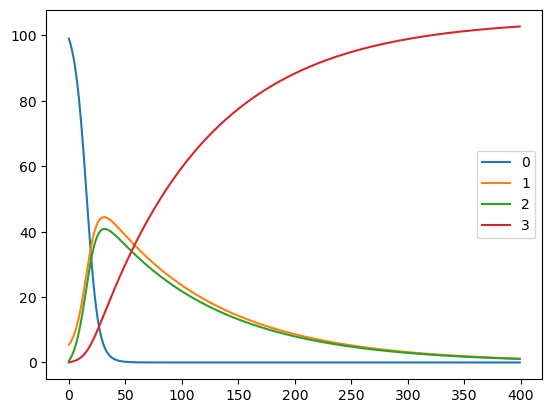

In [ ]:
pd.DataFrame(gathered).plot()

In [ ]:
hdata.query(disease_state_strat["I"]).data.sum()

Array(13., dtype=float32)

In [ ]:
hdata.data.sum()

Array(26., dtype=float32)

CompartmentDataContainer:
array([Compartment :[(Stratification: disease_state, 'S')],
       Compartment :[(Stratification: disease_state, 'I'), (Stratification: severity, 'mild')],
       Compartment :[(Stratification: disease_state, 'I'), (Stratification: severity, 'severe')],
       Compartment :[(Stratification: disease_state, 'R')]], dtype=object)Array([-2.15625 ,  7.911459, 10.244792, 10.      ], dtype=float32)

In [ ]:
params["foi"]

Array(0.5, dtype=float32)

In [ ]:
hdata

CompartmentDataContainer:
array([Compartment :[(Stratification: disease_state, 'S')],
       Compartment :[(Stratification: disease_state, 'I'), (Stratification: severity, 'mild')],
       Compartment :[(Stratification: disease_state, 'I'), (Stratification: severity, 'severe')],
       Compartment :[(Stratification: disease_state, 'R')]], dtype=object)Array([ 1.       ,  4.       ,  7.0000005, 10.       ], dtype=float32)

In [ ]:
reconcile_broadcast(
    humans.query(disease_state_strat["S"]), humans.query(disease_state_strat["I"])
)

(CompartmentContainer view of 0x2652047741952:
 array([Compartment :[(Stratification: disease_state, 'S')],
        Compartment :[(Stratification: disease_state, 'S')]], dtype=object)array([0, 0]),
 CompartmentContainer view of 0x2652047741952:
 array([Compartment :[(Stratification: disease_state, 'I'), (Stratification: severity, 'mild')],
        Compartment :[(Stratification: disease_state, 'I'), (Stratification: severity, 'severe')]],
       dtype=object)array([1, 2]),
 array([0.5, 0.5]))

In [ ]:
hdata

CompartmentDataContainer:
array([Compartment :[(Stratification: disease_state, 'S')],
       Compartment :[(Stratification: disease_state, 'I'), (Stratification: severity, 'mild')],
       Compartment :[(Stratification: disease_state, 'I'), (Stratification: severity, 'severe')],
       Compartment :[(Stratification: disease_state, 'R')]], dtype=object)Array([ 1.       ,  4.       ,  7.0000005, 10.       ], dtype=float32)

In [ ]:
susc = humans.query(disease_state_strat["S"])

In [ ]:
severity = list(humans.stratifications)[1]

In [ ]:
strats_for_cmap(humans.query(disease_state_strat["S"]))

[Stratification: disease_state]

In [ ]:
humans

CompartmentContainer:
array([Compartment :[(Stratification: disease_state, 'S')],
       Compartment :[(Stratification: disease_state, 'I'), (Stratification: severity, 'mild')],
       Compartment :[(Stratification: disease_state, 'I'), (Stratification: severity, 'severe')],
       Compartment :[(Stratification: disease_state, 'R')]], dtype=object)

In [ ]:
a = []
for slist in [strats_for_comp(c) for c in humans.compartments]:
    a.extend(slist)

a = set()
a.a

AttributeError: 'set' object has no attribute 'a'

In [ ]:
a

[[Stratification: disease_state],
 [Stratification: severity, Stratification: disease_state],
 [Stratification: severity, Stratification: disease_state],
 [Stratification: disease_state]]

In [ ]:
strats_for_comp(c)

[Stratification: disease_state]

In [ ]:
def thing(q):
    

In [ ]:
class Thing:
    pass


t = Thing()

t

In [ ]:
humans_aged.query([disease_state_strat["S"]])

CompartmentContainer view of 0x2219570427728:
array([Compartment :[(Stratification: disease_state, 'S'), (Stratification: age, 'child')],
       Compartment :[(Stratification: disease_state, 'S'), (Stratification: age, 'young_adult')],
       Compartment :[(Stratification: disease_state, 'S'), (Stratification: age, 'adult')],
       Compartment :[(Stratification: disease_state, 'S'), (Stratification: age, 'older')]],
      dtype=object)array([0, 1, 2, 3])

In [ ]:
humans_aged.query([disease_state_strat["I"]])

CompartmentContainer view of 0x2219570427728:
array([Compartment :[(Stratification: disease_state, 'I'), (Stratification: age, 'child')],
       Compartment :[(Stratification: disease_state, 'I'), (Stratification: age, 'young_adult')],
       Compartment :[(Stratification: disease_state, 'I'), (Stratification: age, 'adult')],
       Compartment :[(Stratification: disease_state, 'I'), (Stratification: age, 'older')]],
      dtype=object)array([4, 5, 6, 7])

In [ ]:
def 

In [ ]:
class TransitionFlowMap:
    def __init__(self, source_query, dest_query):
        self.source_query = source_query
        self.dest_query = dest_query

    def get_indices(self, cmap):
        s_idx = cmap.query(self.source_query)
        d_idx = cmap.query(self.dest_query)
        return s_idx, d_idx

In [ ]:
non_infected = (disease_state_strat, ["S", "R"])
children = (h_age_strat, ["child"])

In [ ]:
qres2 = humans_aged.query([non_infected, children])
qres2

CompartmentView of <proto.CompartmentMap object at 0x000002033CC17390>:
array([Compartment :[(Stratification: disease_state, 'S'), (Stratification: age, 'child')],
       Compartment :[(Stratification: disease_state, 'R'), (Stratification: age, 'child')]],
      dtype=object)array([0, 8])

In [ ]:
CompartmentGroup([(disease_state_strat, "R")]).query(qres)

CompartmentView of CompartmentView of <proto.CompartmentMap object at 0x000002033CC17390>:
array([Compartment :[(Stratification: disease_state, 'S'), (Stratification: age, 'child')],
       Compartment :[(Stratification: disease_state, 'R'), (Stratification: age, 'child')]],
      dtype=object)array([0, 8]):
array([Compartment :[(Stratification: disease_state, 'R'), (Stratification: age, 'child')]],
      dtype=object)array([1])

In [ ]:
humans_aged.compartments[qres.indices] == qres.compartments

array([ True,  True])

In [ ]:
class TransitionFlowCompartmentMap:
    def __init__(self, source: CompartmentView, dest: CompartmentView, value_map):
        self.source = source
        self.dest = dest
        self.value_map = value_map
        self.adjustments = []

In [ ]:
def remap_transition_flow_comps(flow_map, remapped_comps, map_rules=None):
    out_source = []
    out_dest = []
    out_value_map = []
    for src_c, dest_c, value in zip(flow_map.source, flow_map.dest, flow_map.value_map):
        new_src = remapped_comps[src_c]
        new_dest = remapped_comps[dest_c]

        if len(new_src) != len(new_dest):
            if map_rules is None:
                print(new_src, new_dest)
                raise ValueError(
                    "No flow map rules supplied for mismatched compartments"
                )

        out_value_map.extend([value] * len(new_src))
        out_source.extend(new_src)
        out_dest.extend(new_dest)

    return TransitionFlowCompartmentMap(out_source, out_dest, out_value_map)

In [ ]:
infection_orig = TransitionFlowCompartmentMap(
    humans.compartments[0:1], humans.compartments[1:2], ["irate"]
)
infection_orig.source

array([Compartment :[(Stratification: disease_state, 'S')]], dtype=object)

In [ ]:
infection_one_strat = remap_transition_flow_comps(infection_orig, remapped_comps)
infection_one_strat.source, infection_one_strat.dest, infection_one_strat.value_map

([Compartment :[(Stratification: disease_state, 'S'), (Stratification: age, 'child')],
  Compartment :[(Stratification: disease_state, 'S'), (Stratification: age, 'young_adult')],
  Compartment :[(Stratification: disease_state, 'S'), (Stratification: age, 'adult')],
  Compartment :[(Stratification: disease_state, 'S'), (Stratification: age, 'older')]],
 [Compartment :[(Stratification: disease_state, 'I'), (Stratification: age, 'child')],
  Compartment :[(Stratification: disease_state, 'I'), (Stratification: age, 'young_adult')],
  Compartment :[(Stratification: disease_state, 'I'), (Stratification: age, 'adult')],
  Compartment :[(Stratification: disease_state, 'I'), (Stratification: age, 'older')]],
 ['irate', 'irate', 'irate', 'irate'])

In [ ]:
CompartmentGroup([(h_age_strat, "child")]).query(infection_one_strat.source)

AttributeError: 'list' object has no attribute 'compartments'

In [ ]:
humans_sev, severity_strat, sev_remapped_comps = humans.stratify(
    Stratification("severity", ["asymp", "mild", "severe"]),
    (disease_state_strat, "I"),
    in_place=False,
)
humans_sev.compartments

array([Compartment :[(Stratification: disease_state, 'S')],
       Compartment :[(Stratification: disease_state, 'I'), (Stratification: severity, 'asymp')],
       Compartment :[(Stratification: disease_state, 'I'), (Stratification: severity, 'mild')],
       Compartment :[(Stratification: disease_state, 'I'), (Stratification: severity, 'severe')],
       Compartment :[(Stratification: disease_state, 'R')]], dtype=object)

In [ ]:
infection_sev_strat = remap_transition_flow_comps(infection_orig, sev_remapped_comps)

[Compartment :[(Stratification: disease_state, 'S')]] [Compartment :[(Stratification: disease_state, 'I'), (Stratification: severity, 'asymp')], Compartment :[(Stratification: disease_state, 'I'), (Stratification: severity, 'mild')], Compartment :[(Stratification: disease_state, 'I'), (Stratification: severity, 'severe')]]


ValueError: No flow map rules supplied for mismatched compartments

In [ ]:
cat_indices = [base_cg.query(c).indices for c in infection_cats]


def category_idx_reduction(cat_indices: list[np.ndarray], src: jax.Array):
    if len(set([len(c) for c in cat_indices])) == 1:
        return src[np.array(cat_indices)].sum(axis=1)
    else:
        return jnp.array([src[c].sum() for c in cat_indices])